<a href="https://colab.research.google.com/github/Govind-2004/ICT_Assessment_and_Assignment/blob/main/CV_CIFAR_100_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import pickle     # for loading dataset
import cv2
from sklearn.model_selection import train_test_split
import os

# Read Data

In [ ]:
dataset_path = "/content/drive/MyDrive/CIFAR-100"

# Load dataset
def load_file(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data

train = load_file(dataset_path + "/train")
test = load_file(dataset_path + "/test")

In [ ]:
# Splitting to train and test data
X_train = train[b'data']
y_train = np.array(train[b'fine_labels'])

X_test = test[b'data']
y_test = np.array(test[b'fine_labels'])

#Data Preprocessing

In [ ]:
print("Number of classes of dataset:", len(np.unique(y_train)))

Number of classes of dataset: 100


In [ ]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (50000, 3072)
Training Labels: (50000,)
Testing Images: (10000, 3072)
Testing Labels: (10000,)


In [ ]:
print(X_train.dtype)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

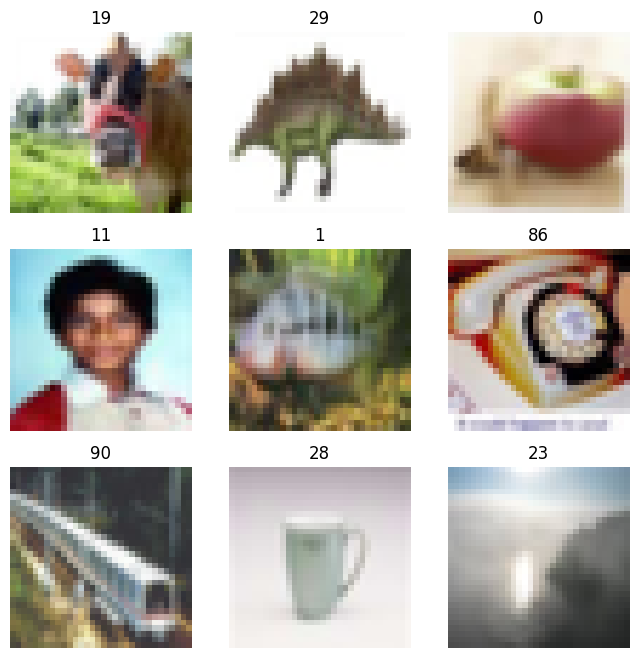

In [ ]:
plt.figure(figsize = (8,8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [ ]:
# First, select 6000 images from the original training set
X_subset, _, y_subset, _ = train_test_split(
    X_train,
    y_train,
    train_size = 6000,
    stratify = y_train,
    random_state = 42
)

# Now split the 6000 images into 80% train and 20% test
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_subset,
    y_subset,
    test_size = 0.2,
    stratify = y_subset,
    random_state = 42
)

print(X_train_small.shape)
print(y_train_small.shape)
print(X_test_small.shape)
print(y_test_small.shape)

(4800, 32, 32, 3)
(4800,)
(1200, 32, 32, 3)
(1200,)


In [ ]:
# Normalization

X_train_cnn = X_train_small.astype("float32") / 255.0
X_test_cnn = X_test_small.astype("float32") / 255.0

In [ ]:
# Onehot encode the labels

y_train_cnn = to_categorical(y_train_small, 100)
y_test_cnn = to_categorical(y_test_small, 100)

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
)

#Model Building

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Block 1
    tf.keras.layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.2),

    # Block 2
    tf.keras.layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.3),

    # Block 3
    tf.keras.layers.Conv2D(256, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.4),

    # Block 4
    tf.keras.layers.Conv2D(512, (3,3), padding = 'same', activation = 'relu',
                            kernel_initializer = 'he_normal',
                            kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.4),

    # Classifier
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation = 'relu', kernel_initializer = 'he_normal',
                           kernel_regularizer = tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(100, activation = 'softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,647,204 (10.10 MB)

 Trainable params: 2,643,364 (10.08 MB)

 Non-trainable params: 3,840 (15.00 KB)

## Compile Model

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

##Training

In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

checkpoint = ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor = 'val_accuracy',
    save_best_only = True,
    mode = 'max',
    verbose = 1
)

In [ ]:
# Model Training

history = model.fit(
    train_datagen.flow(X_train_cnn, y_train_cnn, batch_size = 32),
    epochs = 30,
    validation_data = (X_test_cnn, y_test_cnn),
    callbacks = [early_stop, checkpoint]
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0203 - loss: 5.9215
Epoch 1: val_accuracy improved from None to 0.02167, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.0260 - loss: 5.6703 - val_accuracy: 0.0217 - val_loss: 5.7264
Epoch 2/30
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0423 - loss: 5.1990
Epoch 2: val_accuracy improved from 0.02167 to 0.03917, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.0494 - loss: 5.1369 - val_accuracy: 0.0392 - val_loss: 5.1948
Epoch 3/30
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0560 - loss: 4.9353
Epoch 3: val_accuracy improved from 0.03917 to 0.07667, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy

##Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test_cnn, y_test_cnn)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2792 - loss: 3.4662
Test Loss: 3.4662203788757324
Test Accuracy: 0.27916666865348816


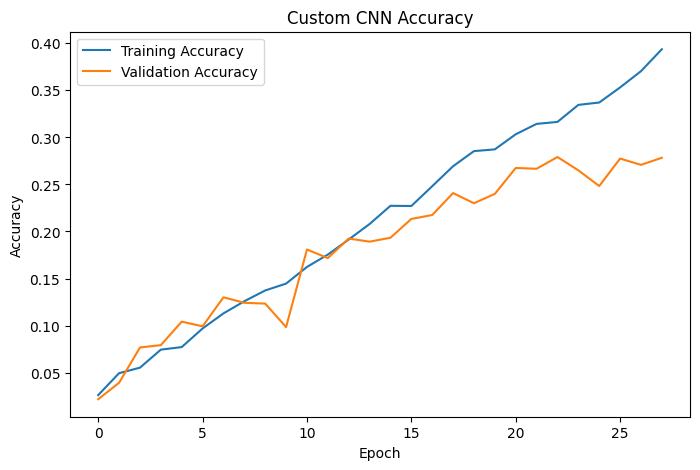

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

plt.title('Custom CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])


Training Accuracy: 0.39375001192092896
Validation Accuracy: 0.2783333361148834
Training Loss: 2.860767364501953
Validation Loss: 3.61796498298645


#VGG

In [ ]:
# base vgg model building
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(100, activation='softmax')(x)

model = Model(base_model.input, outputs)

In [ ]:
# Compiling vgg model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# preprocessing the images for vgg model, vgg model only accept image of size 224
def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224,224))
    image = preprocess_input(image)
    return image, label

In [ ]:
X_train_vgg = X_train_small.astype(np.float32)
X_test_vgg = X_test_small.astype(np.float32)

In [ ]:
# one hot encoding the labels
y_train_vgg = to_categorical(y_train_small, num_classes=100).astype(np.float32)
y_test_vgg = to_categorical(y_test_small, num_classes=100).astype(np.float32)

In [ ]:
# Splitting the preprocessed data as train and test
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_vgg, y_train_vgg))
    .map(preprocess)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test_vgg, y_test_vgg))
    .map(preprocess)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# vgg model training
vgg_history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = 10,
    callbacks = [early_stop, checkpoint]
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.3671 - loss: 2.5155
Epoch 1: val_accuracy improved from 0.36417 to 0.42083, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 275ms/step - accuracy: 0.3646 - loss: 2.5030 - val_accuracy: 0.4208 - val_loss: 2.4137
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4071 - loss: 2.3418
Epoch 2: val_accuracy improved from 0.42083 to 0.43750, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.4162 - loss: 2.3102 - val_accuracy: 0.4375 - val_loss: 2.3106
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4430 - loss: 2.1725
Epoch 3: val_accuracy did not improve from 0.43750
150/150 ━━━━━━━━━━━━━━━━━━━━ 42s 279ms/step - accuracy: 0.4427 - loss: 2.1503 - val_accuracy: 0.4375 - val_loss: 2.2311
Epoch 4/10
150/150 ━━━━

## Evaluation

In [ ]:
vgg_loss, vgg_accuracy = model.evaluate(val_dataset)

print("Test Loss:", vgg_loss)
print("Test Accuracy:", vgg_accuracy)


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.4817 - loss: 1.9432
Test Loss: 1.9431846141815186
Test Accuracy: 0.4816666543483734


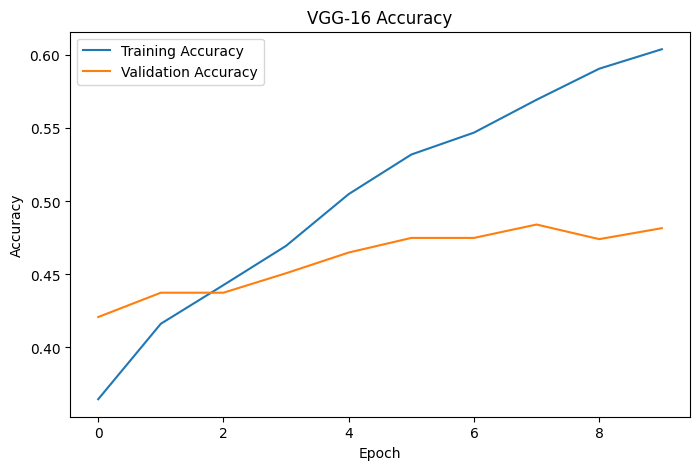

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(vgg_history.history['accuracy'], label = 'Training Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label = 'Validation Accuracy')

plt.title('VGG-16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


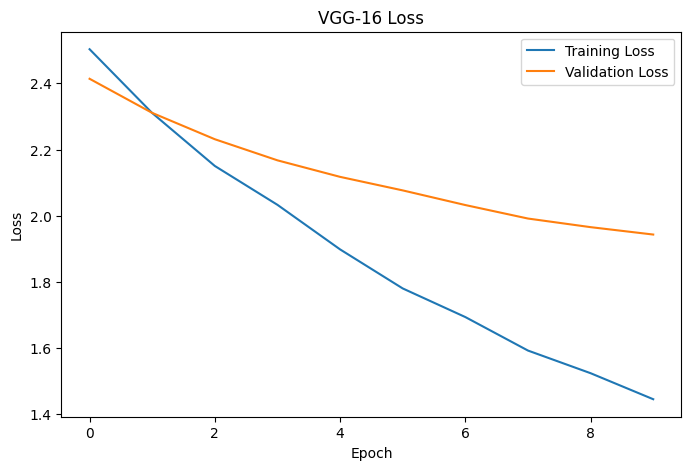

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(vgg_history.history['loss'], label = 'Training Loss')
plt.plot(vgg_history.history['val_loss'], label = 'Validation Loss')

plt.title('VGG-16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
print("Training Accuracy:", vgg_history.history['accuracy'][-1])
print("Validation Accuracy:", vgg_history.history['val_accuracy'][-1])

print("Training Loss:", vgg_history.history['loss'][-1])
print("Validation Loss:", vgg_history.history['val_loss'][-1])


Training Accuracy: 0.6041666865348816
Validation Accuracy: 0.4816666543483734
Training Loss: 1.4457764625549316
Validation Loss: 1.9431846141815186


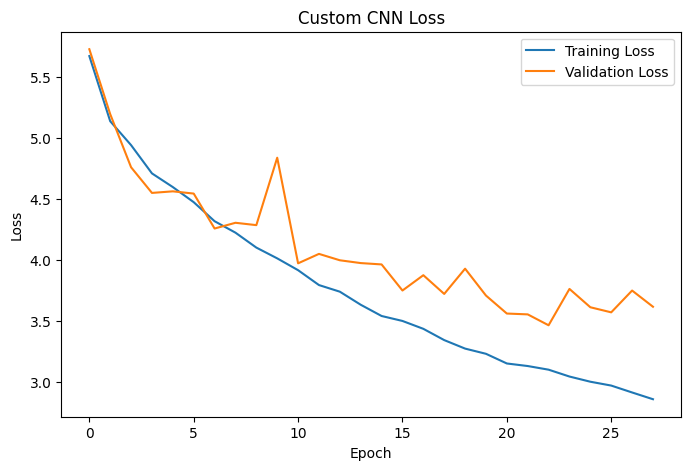

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')

plt.title('Custom CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG-16'],
    'Train Accuracy': [history.history['accuracy'][-1], vgg_history.history['accuracy'][-1]],
    'Validation Accuracy': [history.history['val_accuracy'][-1], vgg_history.history['val_accuracy'][-1]],
    'Test Accuracy': [accuracy, vgg_accuracy],
    'Test Loss': [loss, vgg_loss]
})

comparison_df


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss
0,Custom CNN,0.393750,0.278333,0.279167,3.466220
1,VGG-16,0.604167,0.481667,0.481667,1.943185
